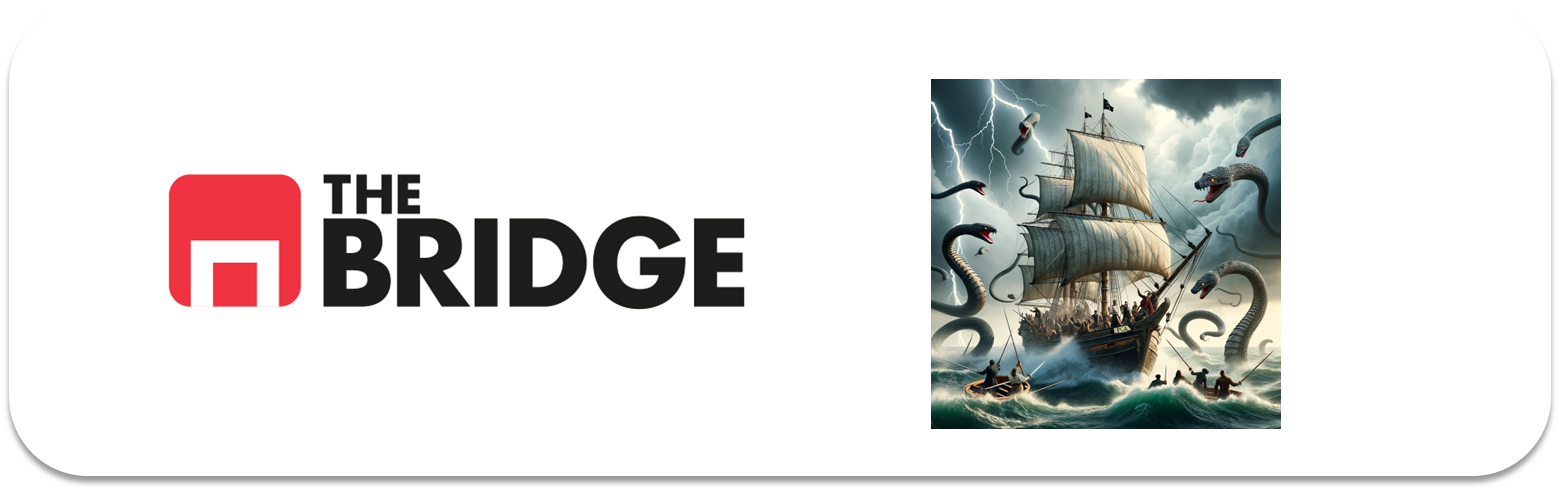

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técnicas de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter
from lightgbm import LGBMClassifier
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel, RFE, SequentialFeatureSelector
from sklearn.metrics import mutual_info_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from xgboost import XGBClassifier


### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


*Pasos ML:*  

*1. Entender Problema -> Tener claro lo siguiente: tipo de aprendizaje, modelos posibles, target o no, métrica o sistema de evaluación (para no supervisados esto es muy importante). EN ESTA PRACTICA nos quedamos con modelo supervisado de clasificación con target en predecir la posible deuda de más de 90 días en los próximos dos años, y métrica el recall medio (por lo desbalancedo del target aunque todavía no lo hayamos visto :-))*   
  
*2. Cargar datos, primer vistazo*

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

*Tal y como nos indican en el enunciado nos deshacemos de las filas con nulos. Esto es porque es un ejercicio académico, pero en la vida real ¿qué implicación tiene deshacerse de filas con nulos? Que en los datos futuros para predecir tendremos que tener todas las columnas informadas o reconstruirlo de alguna forma* 

In [4]:
df.dropna(inplace = True) # df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

In [5]:
target = "SeriousDlqin2yrs"

3. Train y Test


In [6]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state= 42, stratify=df["SeriousDlqin2yrs"])

4. MiniEDA

*4.1 Análisis del target*

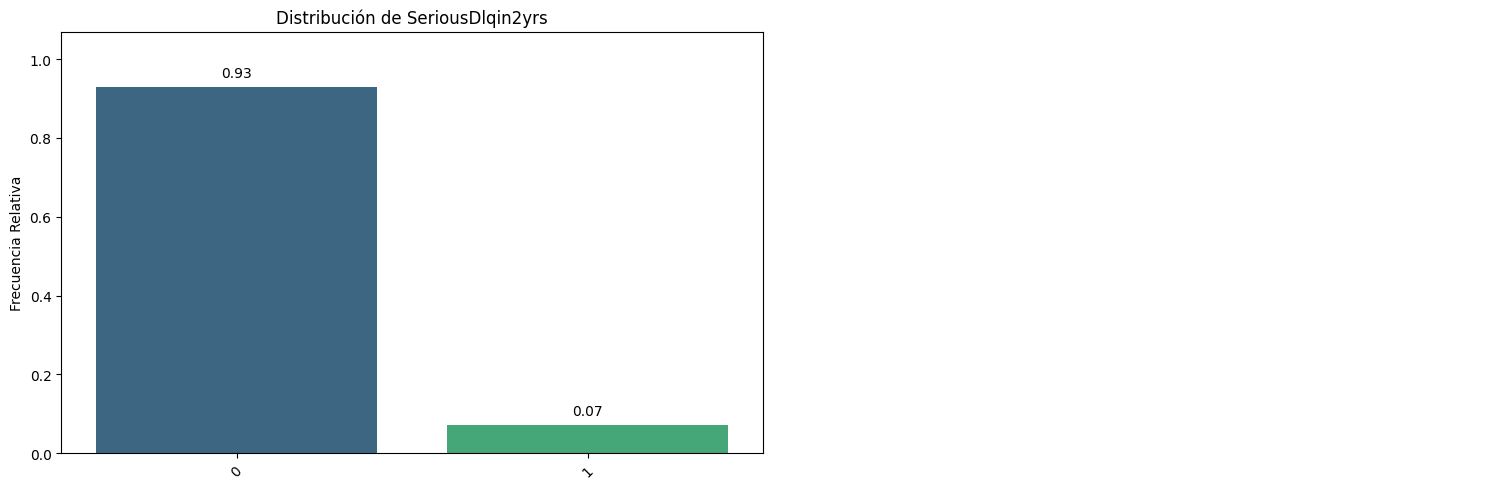

In [7]:
bt.pinta_distribucion_categoricas(train_set, [target], True, True)

*Ya conocíamos este dataset en el que hay un desequilibrio importante. Aunque vamos a emplear el recall medio ("balanced_accuracy") este tipo de desequilibrios en general piden unas metricas más de clase, es decir la precisión de la clase mayoritaria o el recall de la minoritaria o viceversa*

*4.2 Clasificación y transformación de las variables: Vamos a ver cuales son numéricas y cuáles categóricas y además como nos piden que transformemos las variables "NumberOf" en categóricas lo haremos también. Recuerda que si las clasificamos así es porque el tratamiento y análisis es diferente según sean de un tipo u otro.*

*Para ver si son categóricas o numéricas podemos utilizar nuestras funciones del toolbox o usar un describe y un hist:*

In [8]:
train_set.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,9452.0,0.070250,0.255581,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,9452.0,0.336250,0.367448,0.0,0.034696,0.177681,0.587535,6.0
age,9452.0,51.473445,14.582557,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,9452.0,0.362146,3.252785,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,9452.0,0.507346,2.711252,0.0,0.144282,0.295119,0.478447,96.0
MonthlyIncome,9452.0,6927.238785,12765.288137,0.0,3498.750000,5450.000000,8333.000000,702500.0
NumberOfOpenCreditLinesAndLoans,9452.0,8.750529,5.118403,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,9452.0,0.194985,3.218289,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,9452.0,1.067605,1.155821,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,9452.0,0.170123,3.202581,0.0,0.000000,0.000000,0.000000,98.0


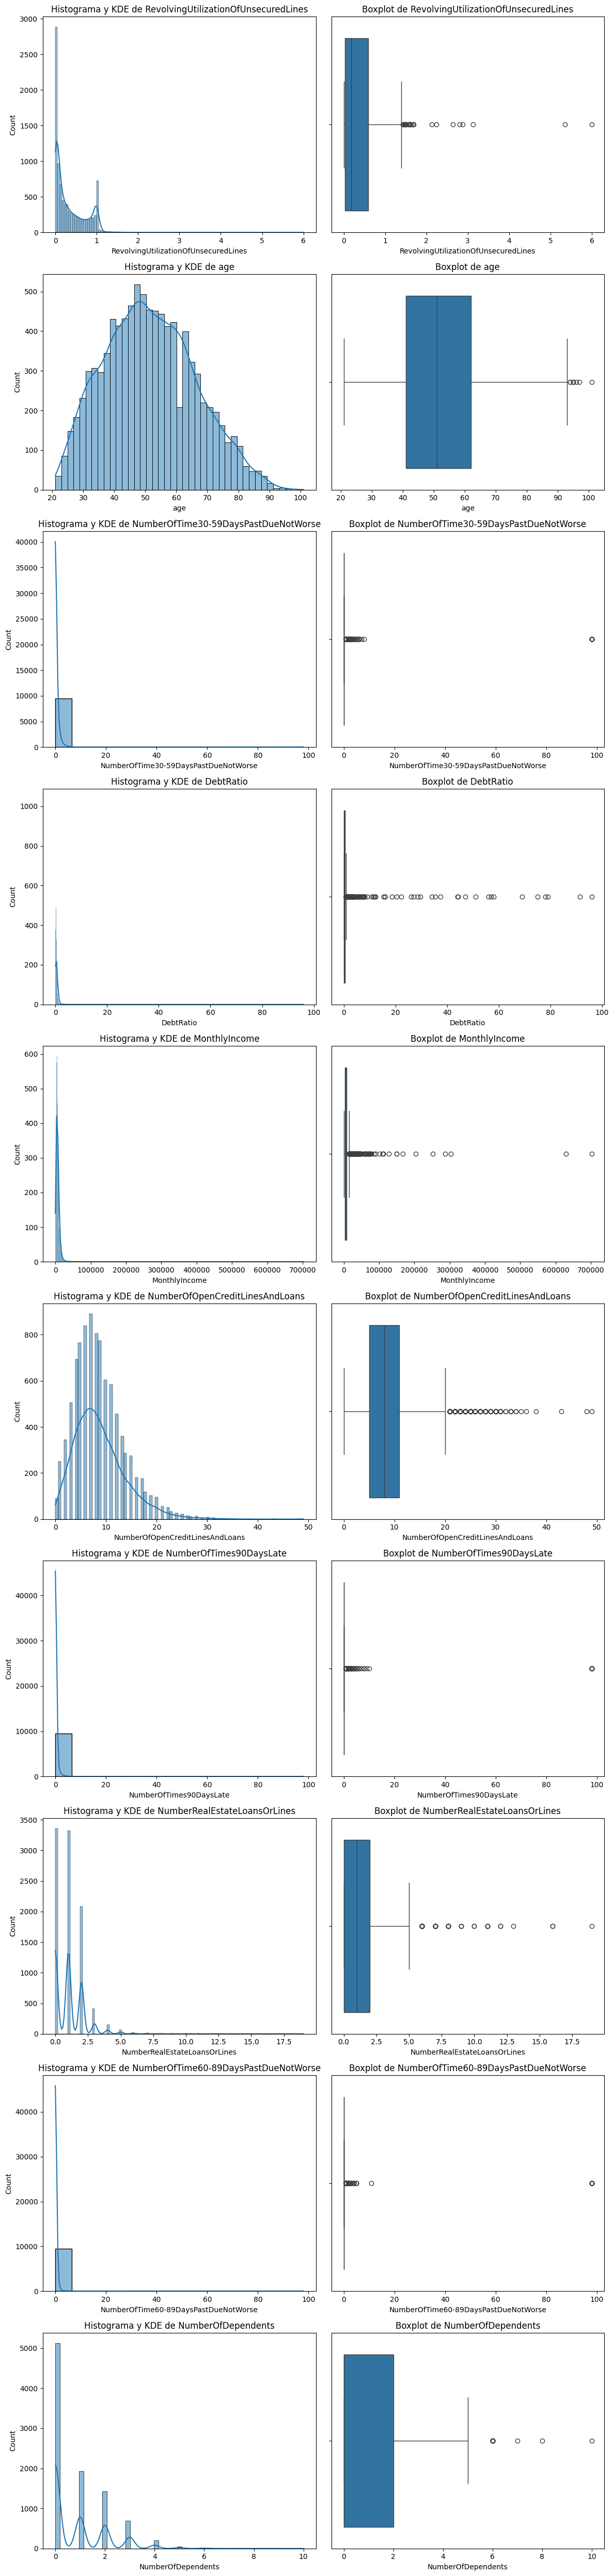

In [9]:
bt.plot_combined_graphs(train_set, [col for col in train_set.columns if col != target])

* *RevolvingUtilizationOfUnsecuredLines*: Númerica continua
* *age*: Numérica discreta
* *NumberOfTime30-59DaysPastDueNotWorse*: El valor 98 lo distorsiona, si nos fijamos en sus quantiles (0) y en el combinado de histograma y caja, es claramente categorizable. Haremos un value_counts para decidir esa categorizacion.
* *DebtRatio*: La consideramos numéricas continuas, por rango y valores.
* *MonthlyIncome*: Numérica continua
* *NumberOfOpenCreditLinesAndLoans*: Numérica discreta pero por cantidad de valores la consideramos numérica continua.
* *NumberOfTimes90DaysLate*: Le ocurre lo mismo que a NumberOfTime30-50DaysPastDueNotWorse. Nos fijaremos en el value_counts para ver su categorización.
* *NumberRealEstateLoansOrLines*: Esta es una feature con outliers dispersos pero que parece concentrada en 5 valores, miraremos su value_counts y su bivariante con el target para tomar una decisión que probablemente será categorizarla. 
* *NumberOfTime60-89DaysPastDueNotWorse*: Como las otras dos variables del estilo (NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate), se concentra en 0 y tiene varios outliers y está sesgada por el valor 98. La categorizaremos después de ver su value_counts.
* *NumberOfDependents*: Numérica discreta que no tocaremos.

*Ya podemos crear la lista de numéricas (continuas y discretas) que vamos a tratar:*

In [10]:
features_num = ["RevolvingUtilizationOfUnsecuredLines",
                "age",
                "DebtRatio",
                "MonthlyIncome",
                "NumberOfOpenCreditLinesAndLoans",
                "NumberOfDependents"]

In [11]:
train_set["NumberOfDependents"].value_counts(True) * 100

NumberOfDependents
0.0     54.274228
1.0     20.366060
2.0     15.033855
3.0      7.352941
4.0      2.158273
5.0      0.560728
6.0      0.222175
10.0     0.010580
7.0      0.010580
8.0      0.010580
Name: proportion, dtype: float64

In [12]:
columnas_numberof = [col for col in df.columns if col.startswith("NumberOf")]
for col in columnas_numberof:
    distribucion_porcentaje = (df[col].value_counts(normalize= True, dropna= False).sort_index())
    
    porcentaje_ceros = distribucion_porcentaje.get(0, 0)
    print(f"\n{col} | valores_unicos =  {df[col].nunique()} | porcentaje_0 = {porcentaje_ceros:.2%}")
    print((distribucion_porcentaje.head(10) * 100).round(2))


NumberOfTime30-59DaysPastDueNotWorse | valores_unicos =  10 | porcentaje_0 = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0     83.09
1     11.46
2      3.36
3      1.07
4      0.54
5      0.19
6      0.17
7      0.01
8      0.02
98     0.08
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores_unicos =  43 | porcentaje_0 = 0.95%
NumberOfOpenCreditLinesAndLoans
0    0.95
1    2.60
2    3.77
3    5.40
4    7.18
5    8.15
6    8.73
7    9.39
8    8.54
9    8.17
Name: proportion, dtype: float64

NumberOfTimes90DaysLate | valores_unicos =  13 | porcentaje_0 = 94.41%
NumberOfTimes90DaysLate
0    94.41
1     3.33
2     1.20
3     0.46
4     0.26
5     0.12
6     0.05
7     0.03
8     0.03
9     0.01
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores_unicos =  8 | porcentaje_0 = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0     94.84
1      4.05
2      0.72
3      0.15
4      0.12
5      0.03
11     0.01
98     0.08
Name: proportion, dtype: 

*Analizamos con un poco más de detalle "NumberRealEstateLoansOrLines" para decidir si categórica o numérica:*

In [13]:
train_set["NumberRealEstateLoansOrLines"].value_counts(True) * 100

NumberRealEstateLoansOrLines
0     35.558612
1     35.209479
2     22.048244
3      4.337706
4      1.576386
5      0.687685
6      0.232755
7      0.116377
8      0.074058
11     0.042319
9      0.031739
10     0.021160
12     0.021160
16     0.021160
13     0.010580
19     0.010580
Name: proportion, dtype: float64

*Existen bastantes valores entre 0 y 4 y ya menos en 5 y a patir de ahí casi no hay instancias (filas del dataframe) con 6 o más. Podríamos crear una categoria "mas de 6" o 7 que incluya todos los valores iguales o por encima de 6, por simplicidad la dejamos tal cual y la consideramos numérica discreta.*  

*¿Pero entonces cuando te quedas una numérica discreta o la consideras categórica? Si tengo tiempo haría las dos consideraciones. ¿La diferencia? El hecho de que los valores 6 a 19 los convertiría en un único valor "7" y luego trataría ambas como ordinales (no haría otra codificación). Probaría las "dos" features por ver cual aporta más. Como no tenemos más tiempo, lo dejo en numérica discreta, en definitiva, no la toco*

In [14]:
features_num.append("NumberRealEstateLoansOrLines")

In [15]:
features_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

*Categoricemos NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate:*

In [16]:
train_set["NumberOfTime30-59DaysPastDueNotWorse"].value_counts(True)

NumberOfTime30-59DaysPastDueNotWorse
0     0.829454
1     0.114896
2     0.034596
3     0.011109
4     0.005396
5     0.001799
6     0.001481
98    0.001058
7     0.000106
8     0.000106
Name: proportion, dtype: float64

*Una regla del dedo gordo, hacer "categorias" de cualquier valor discreto con 10% o más de instancias. En este caso aplicando esa regla tendríamos 0,1, y +de 1. Voy a hacer 3 y las voy a "codificar" ya como 0,1,2*

In [17]:
n_corto = "NumberOfTime30-59DaysPastDueNotWorse"
train_set[train_set[target] == 0][n_corto].value_counts(True)

NumberOfTime30-59DaysPastDueNotWorse
0     0.853550
1     0.104802
2     0.027538
3     0.008193
4     0.003414
5     0.001138
6     0.000797
98    0.000341
7     0.000114
8     0.000114
Name: proportion, dtype: float64

In [18]:
n_corto = "NumberOfTime30-59DaysPastDueNotWorse"
train_set[train_set[target] == 1][n_corto].value_counts(True)

NumberOfTime30-59DaysPastDueNotWorse
0     0.510542
1     0.248494
2     0.128012
3     0.049699
4     0.031627
98    0.010542
6     0.010542
5     0.010542
Name: proportion, dtype: float64

In [19]:
# Me simplifico la vida con el nombre
n_corto = "NumberOfTime30-59DaysPastDueNotWorse"

# Método 1, con pd.cut
labels = [0,1,2] # Cambio 

train_set["N30-59"] = pd.cut(train_set[n_corto], bins = [-1,0,1,np.inf], labels = labels, right= True).astype(int) # right a True para incluir los valores "a la derecha" en el bin (es decir -1,0 incluye a todos los valores >-1 y <= 0)
test_set["N30-59"] = pd.cut(test_set[n_corto], bins = [-1,0,1,np.inf], labels = labels, right= True).astype(int) 
train_set["N30-59"].value_counts(True)


N30-59
0    0.829454
1    0.114896
2    0.055650
Name: proportion, dtype: float64

Además podemos comprobar si esa codificación "refleja" la tendencia a "tener deuda":*

In [20]:
train_set[train_set[target] == 1]["N30-59"].value_counts(True)

N30-59
0    0.510542
1    0.248494
2    0.240964
Name: proportion, dtype: float64

*Viendo esto podríamos incluso haber dejado solo dos categorías (fijate que las frecuencias de "impagadores" son similares para 1 y para 2), pero nos vamos a quedar con las tres por no complicar más el notebook (sí, si tuvieramos más tiempo y espacio lo haríamos con dos categorizaciones también :-). Siguiente*

In [21]:
train_set["NumberOfTime60-89DaysPastDueNotWorse"].value_counts(True)

NumberOfTime60-89DaysPastDueNotWorse
0     0.948688
1     0.040203
2     0.006771
3     0.001587
4     0.001164
98    0.001058
5     0.000423
11    0.000106
Name: proportion, dtype: float64

*Aquí escogemos dos categorías 0 y 1 o más:*

In [22]:
train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0

2031     False
10352    False
497      False
10341    False
4043     False
         ...  
4371     False
5767     False
7494     False
11693    False
5231     False
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 9452, dtype: bool

In [23]:
(train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0).astype(int)

2031     0
10352    0
497      0
10341    0
4043     0
        ..
4371     0
5767     0
7494     0
11693    0
5231     0
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 9452, dtype: int64

In [24]:
train_set["N60-89"] = (train_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
test_set["N60-89"] = (test_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
train_set["N60-89"].value_counts(True)

N60-89
0    0.948688
1    0.051312
Name: proportion, dtype: float64

In [25]:
train_set[train_set[target] == 1]["N60-89"].value_counts(True)

N60-89
0    0.740964
1    0.259036
Name: proportion, dtype: float64

In [26]:
train_set[train_set[target] == 0]["N60-89"].value_counts(True)

N60-89
0    0.964383
1    0.035617
Name: proportion, dtype: float64

*Tiene buena pinta (luego lo analizamos con detalle)*

In [27]:
train_set["NumberOfTimes90DaysLate"].value_counts(True)

NumberOfTimes90DaysLate
0     0.944985
1     0.033432
2     0.011955
3     0.004338
4     0.002433
98    0.001058
5     0.000846
6     0.000423
8     0.000212
10    0.000106
9     0.000106
7     0.000106
Name: proportion, dtype: float64

*Dos categorías 0 y uno o más:*

In [28]:
train_set["N90"] = (train_set["NumberOfTimes90DaysLate"] > 0).astype(int)
test_set["N90"] = (test_set["NumberOfTimes90DaysLate"] > 0).astype(int)
train_set["N90"].value_counts(True)

N90
0    0.944985
1    0.055015
Name: proportion, dtype: float64

In [29]:
train_set[train_set[target] == 1]["N90"].value_counts(True)

N90
0    0.652108
1    0.347892
Name: proportion, dtype: float64

In [30]:
train_set[train_set[target] == 0]["N90"].value_counts(True)

N90
0    0.967114
1    0.032886
Name: proportion, dtype: float64

*Igual que la anterior tiene buena pinta. Y ya tenemos nuestras categóricas:*

In [31]:
features_cat = ["N30-59","N60-89","N90"]
features_cat


['N30-59', 'N60-89', 'N90']

In [32]:
features_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [33]:
target

'SeriousDlqin2yrs'

4.3 **Análisis visual con estadísticos matemáticos**

*Hagamos nuestros análisis bivariantes para hacer la selección de las variables "visualmente", como hemos venido haciendo hasta ahora. Empezamos con las categóricas*

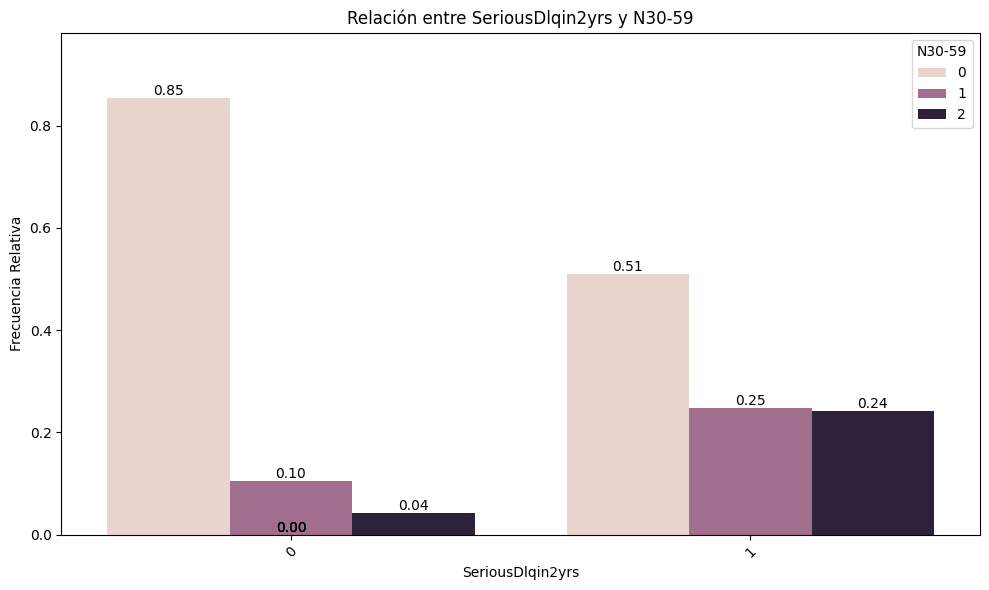

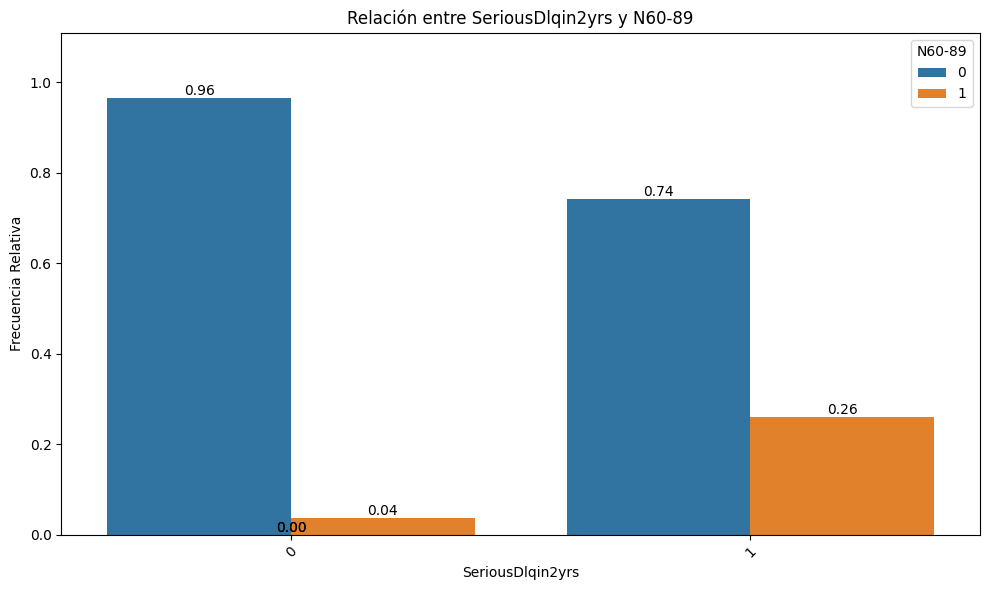

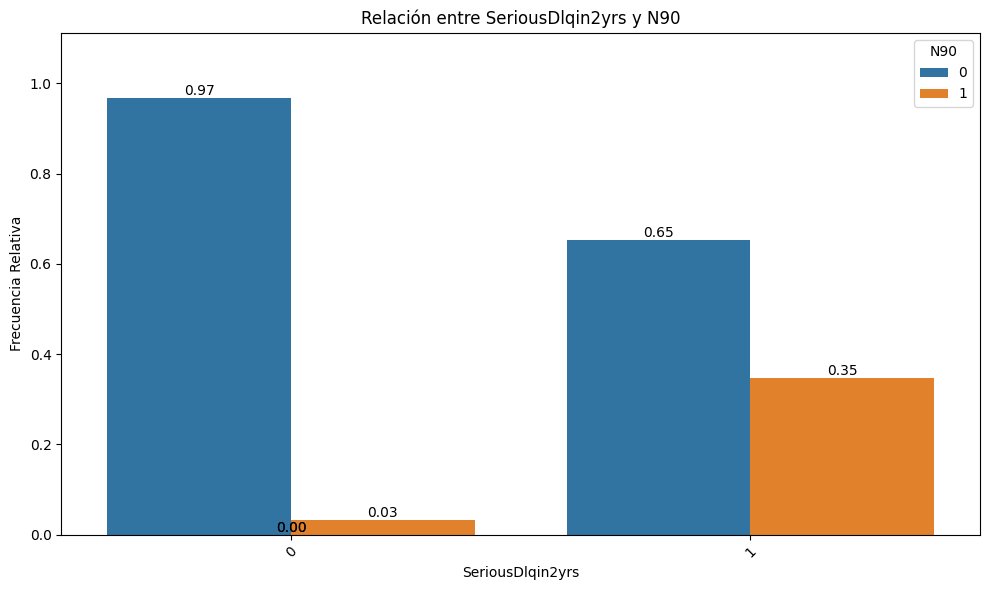

In [34]:
for col in features_cat:
    bt.plot_categorical_relationship(train_set, target, col, True, True)

*Las tres tienen diferencias destacadas según el valor del target, son de "primera división"*

In [35]:
features_visual = features_cat.copy()

*Vamos con las numéricas*

In [36]:
len(features_num + [target])

8

In [37]:
# sns.pairplot(train_set[features_num + [target]], hue = target)

*Graficas demasiado pequeñas, usaremos nuestras tools*

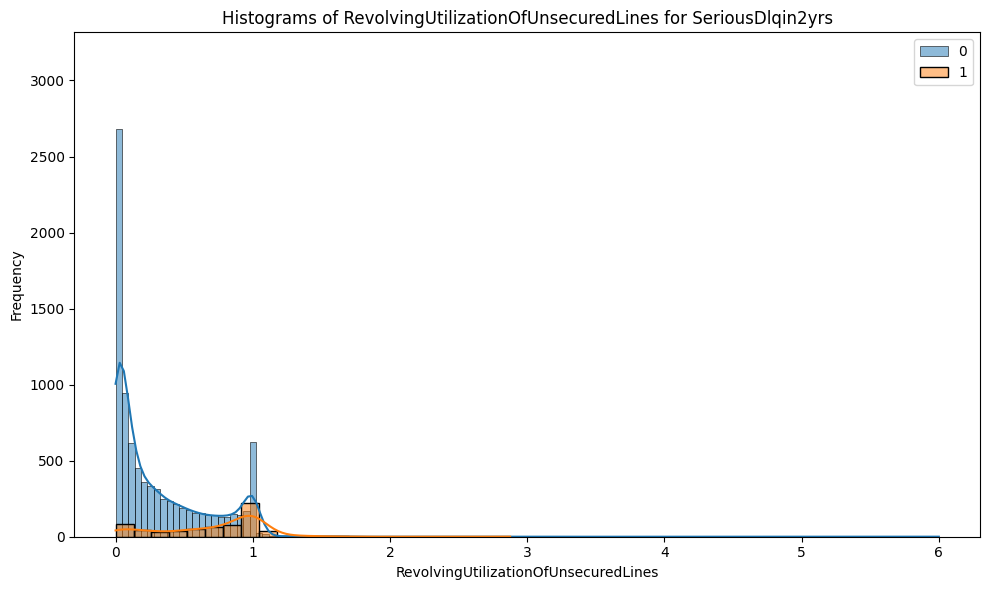

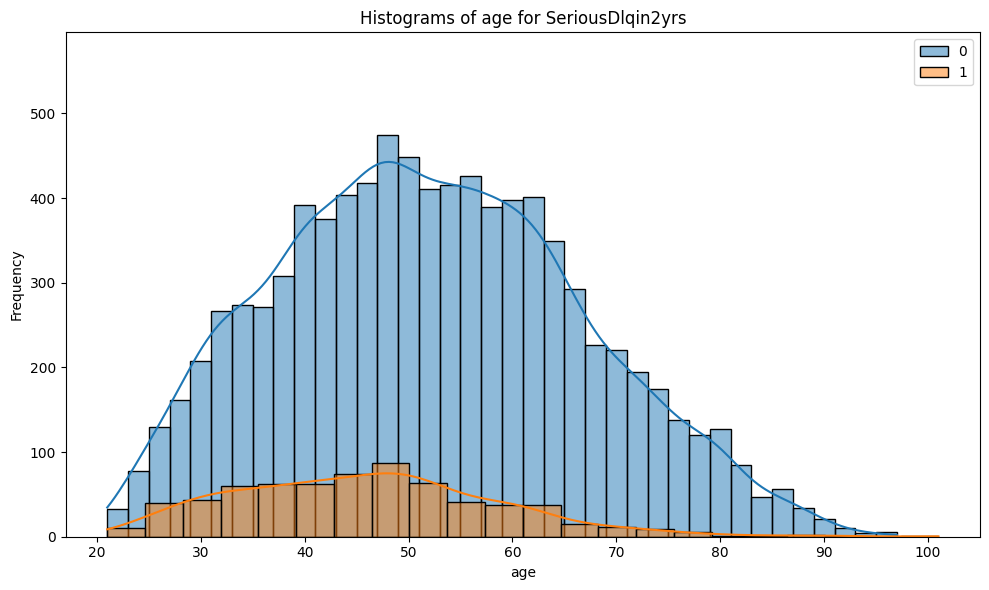

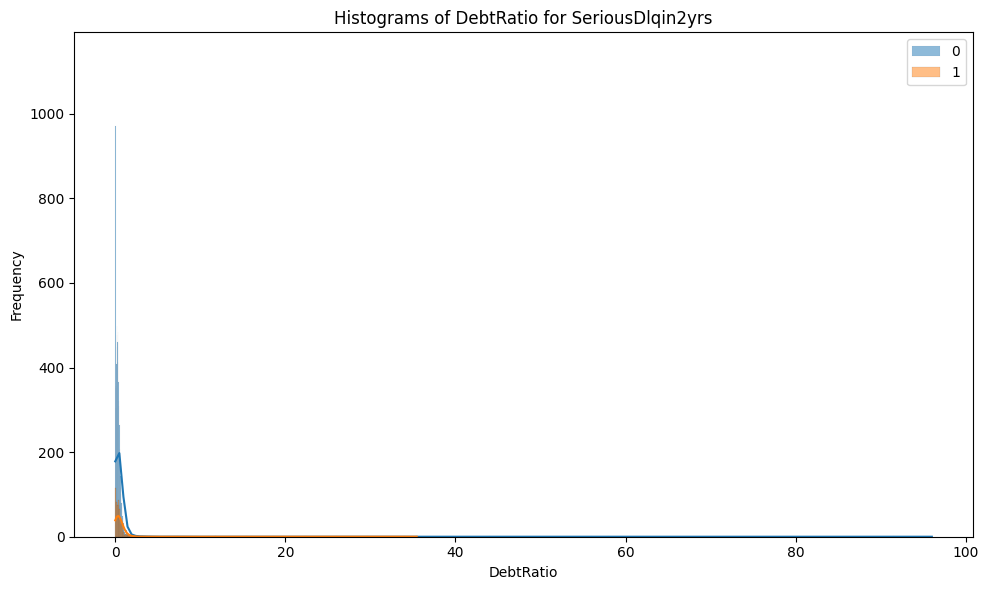

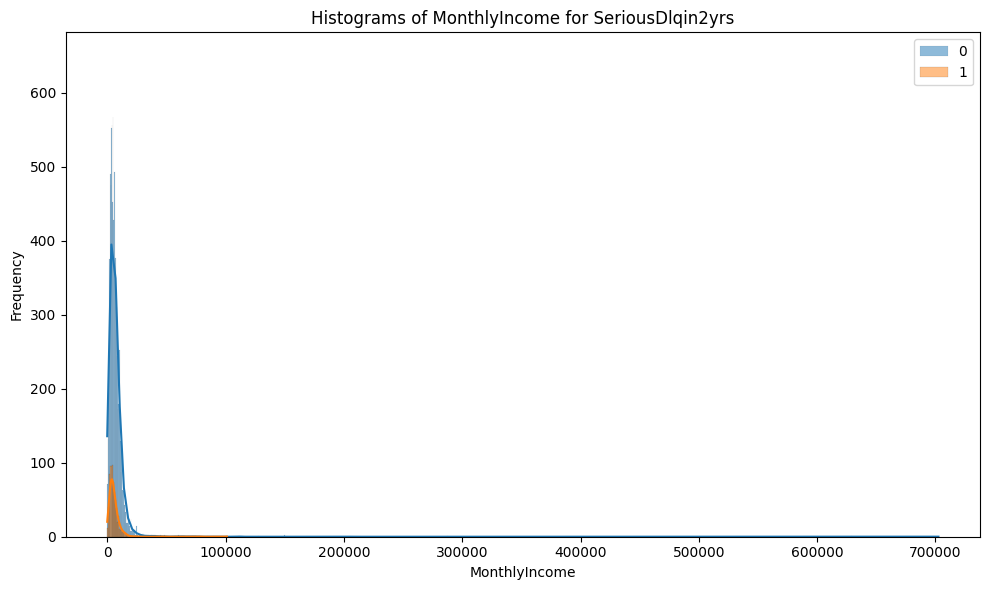

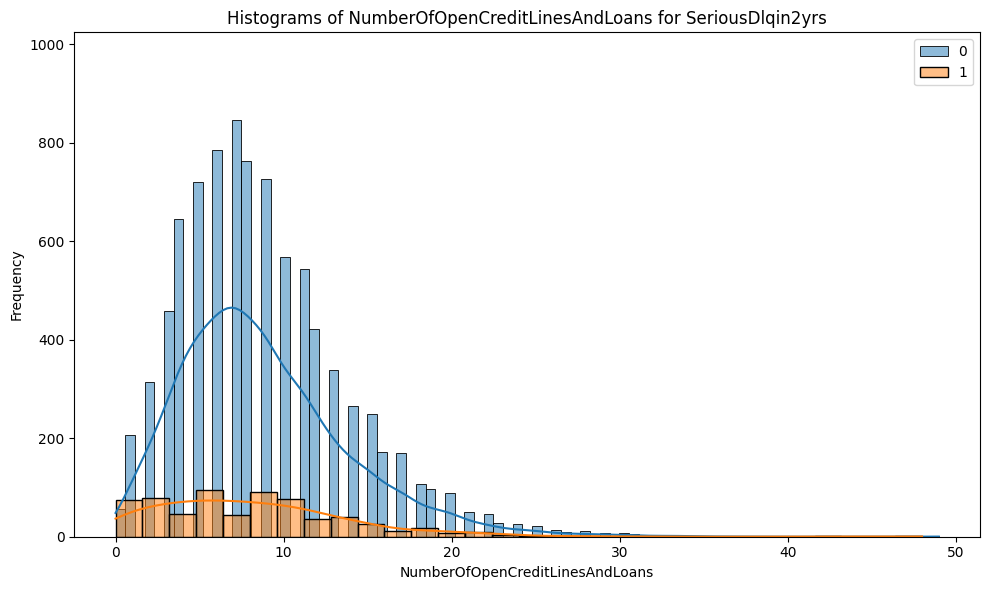

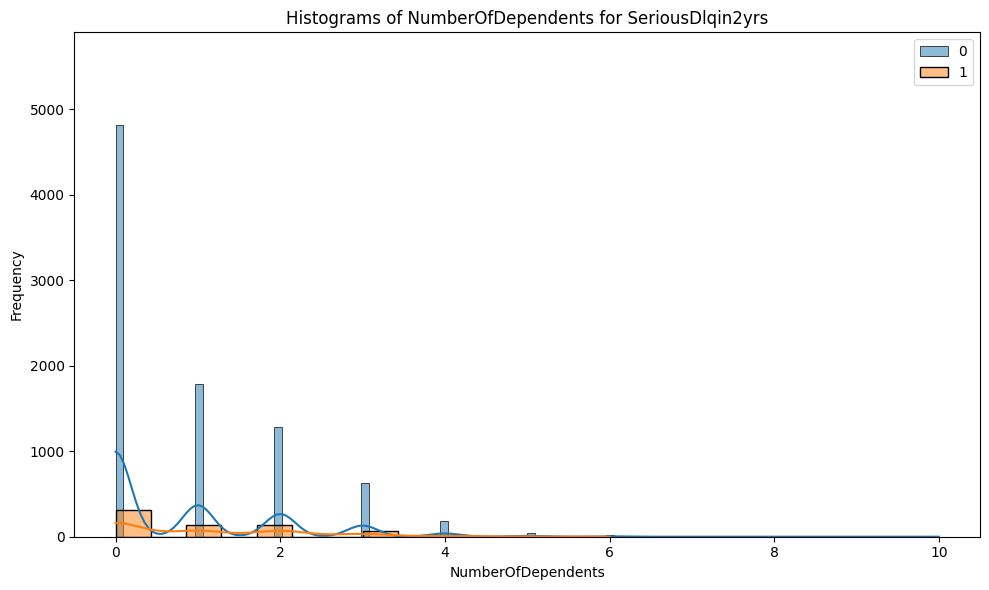

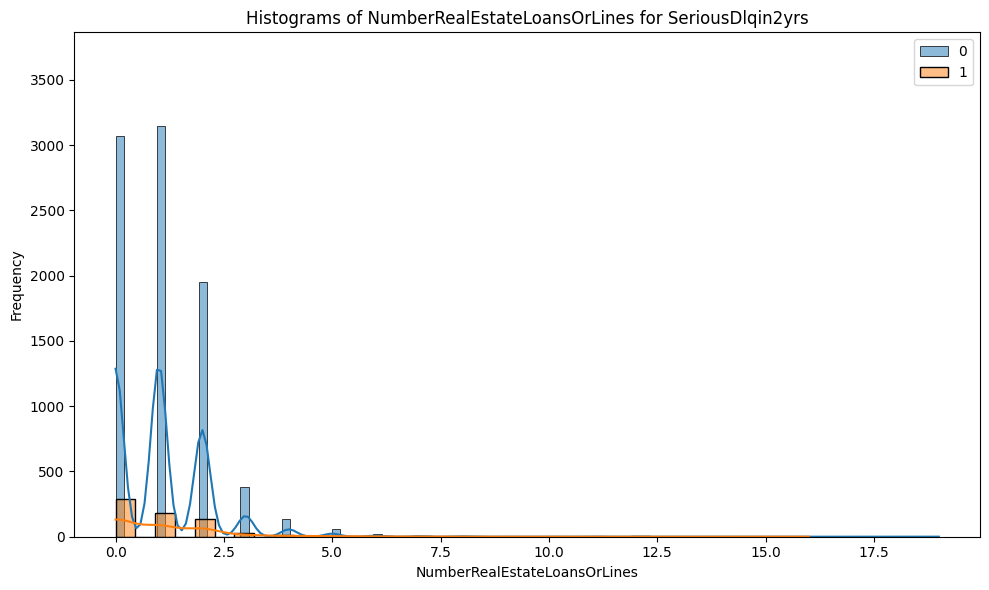

In [38]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

*Podemos hacer unas pequeñas modificaciones al histplot de Seaborn para evitar que el desbalanceo del target no nos deje ver nada:*

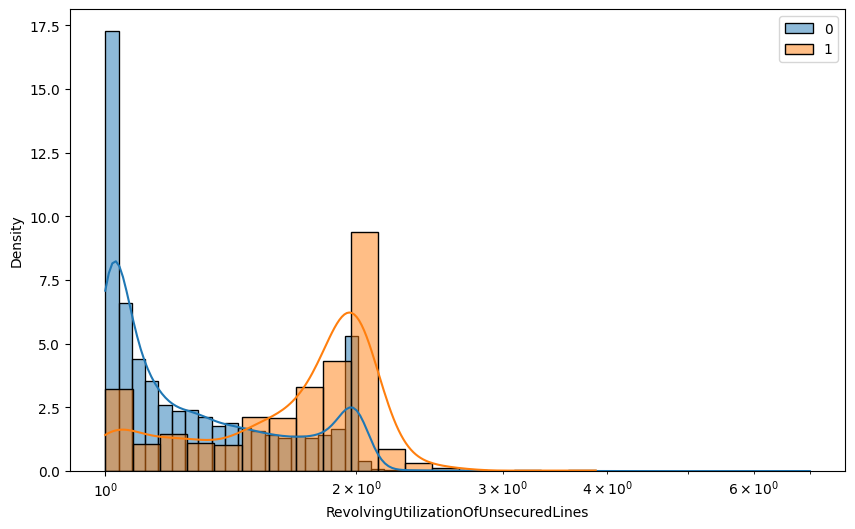

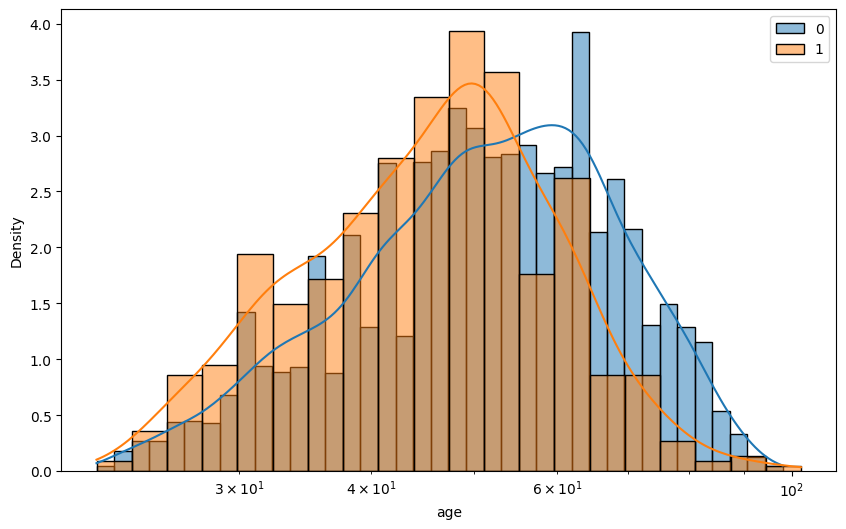

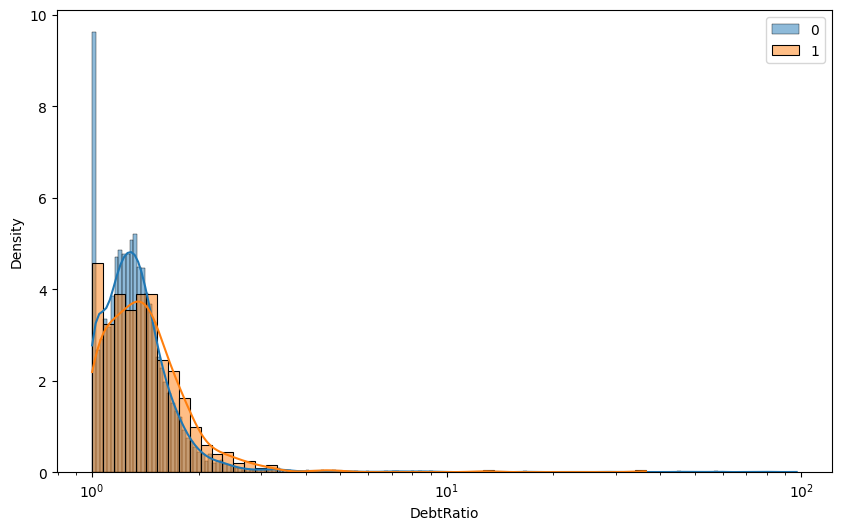

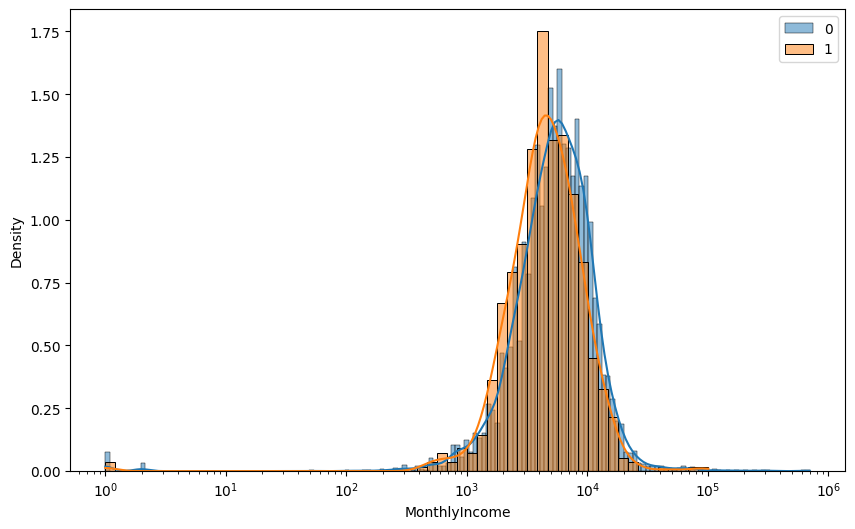

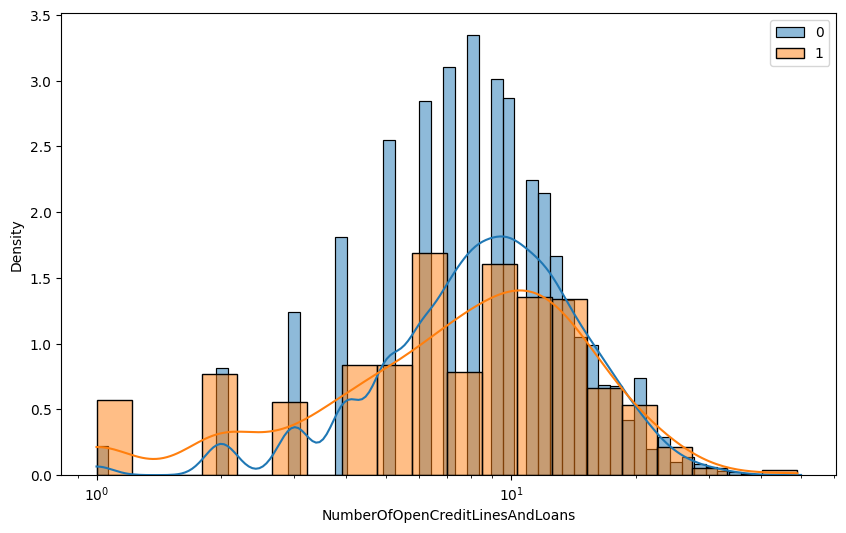

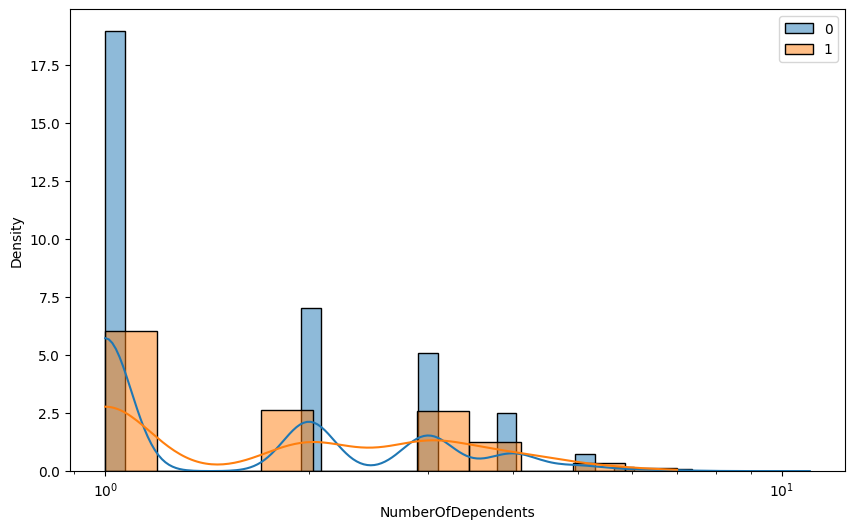

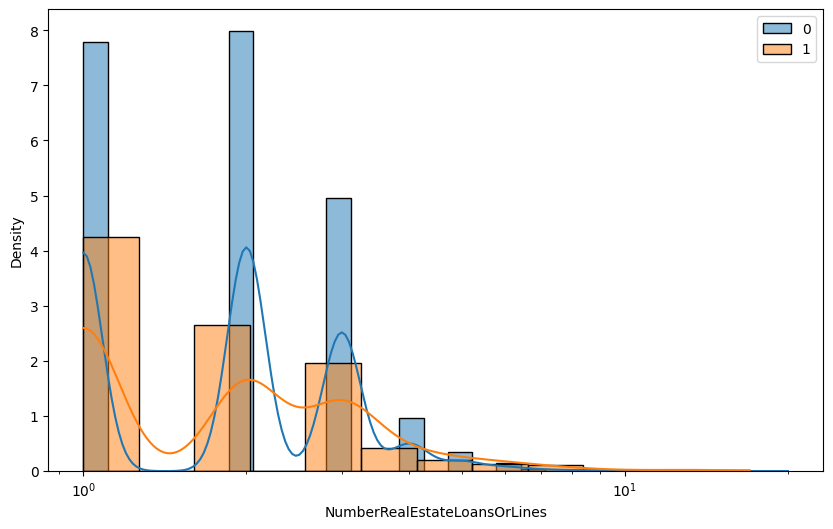

In [39]:
for col in features_num:
    plt.figure(figsize=(10,6))
    sns.histplot(train_set.loc[df[target] == 0] + 1, 
                x=col,
                kde=True,
                stat="density",
                log_scale=10,
                label="0")
    sns.histplot(train_set.loc[df[target] == 1] + 1, 
                x=col, 
                kde=True,
                stat="density",
                log_scale=10,
                label="1")
    plt.legend()
    plt.show()

*Revolving, hay una diferencia marcada en valores bajos, así que me la quedo*


In [40]:
features_visual.append("RevolvingUtilizationOfUnsecuredLines")

*Del resto que me deje tranquilo el quedármela sólo veo "age" que tiene un posible punto (más de 70 años) a partir del cual la relación de pagadores a no pagadores se dispara (vamos que apenas hay inpagadores) (y ahí una relación parecida, pero en menor medida con los menores de 30-35):*

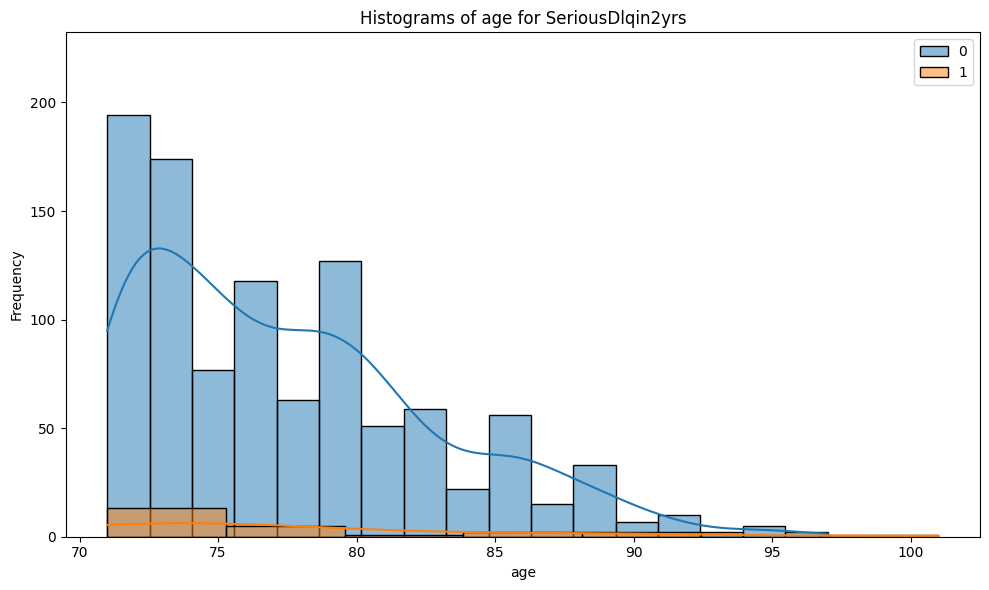

In [41]:
edad_cool = (train_set["age"] > 70)
bt.plot_grouped_histograms(train_set[edad_cool], cat_col = target, num_col= "age", group_size= 2)

*Me la quedo*

In [42]:
features_visual.append("age")

*Hay alguna que ya dejo en segunda división "NumberOfDependents" y "NumberOfOpenCreditsAndLoans" en todas ellas o hay superposición o no se ven puntos de diferenciación claros*

*Tengo dudas, por el efecto de los outliers, en "MonthlyIncome" y "DebtRatio" así que los miro con "cariño":*

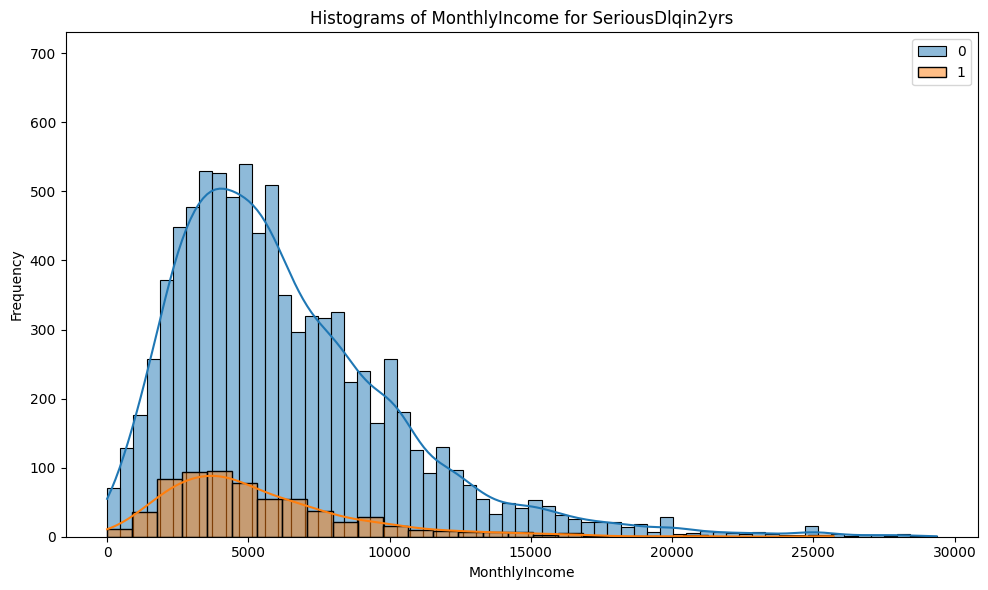

In [43]:
sin_monthlyincome_outliers = train_set["MonthlyIncome"] < 30000 # eL valor se escoge mirando el diagrama de caja, y no hay una regla fija, haz un diagrama de caja y obserfva que a partir de 20000 ya hay muchos outliers, escoger 30000 o 20000 es "indiferente" de primeras
bt.plot_grouped_histograms(train_set[sin_monthlyincome_outliers], cat_col= target, num_col= "MonthlyIncome", group_size= 2)

*Podría mandarla a segunda división, aunque existe un aumento importante de la relacción pagadores sobre no-pagadores a partir de más de 10000 de monthly income que invita a quedársela en "primera". Para asegurarme haré un test de U de Mann-Whitney*

In [44]:
cat_col = target
num_col = "MonthlyIncome"

grupo_a = train_set.loc[train_set[cat_col] == 0][num_col]
grupo_b = train_set.loc[train_set[cat_col] == 1][num_col]

u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 3344578.5
Valor p: 3.022971072848151e-10


In [45]:
p_valor < 0.05

True

*Me la quedo*

In [46]:
features_visual.append("MonthlyIncome")

*Vamos con DebtRatio*

In [47]:
train_set["DebtRatio"].describe()

count    9452.000000
mean        0.507346
std         2.711252
min         0.000000
25%         0.144282
50%         0.295119
75%         0.478447
max        96.000000
Name: DebtRatio, dtype: float64

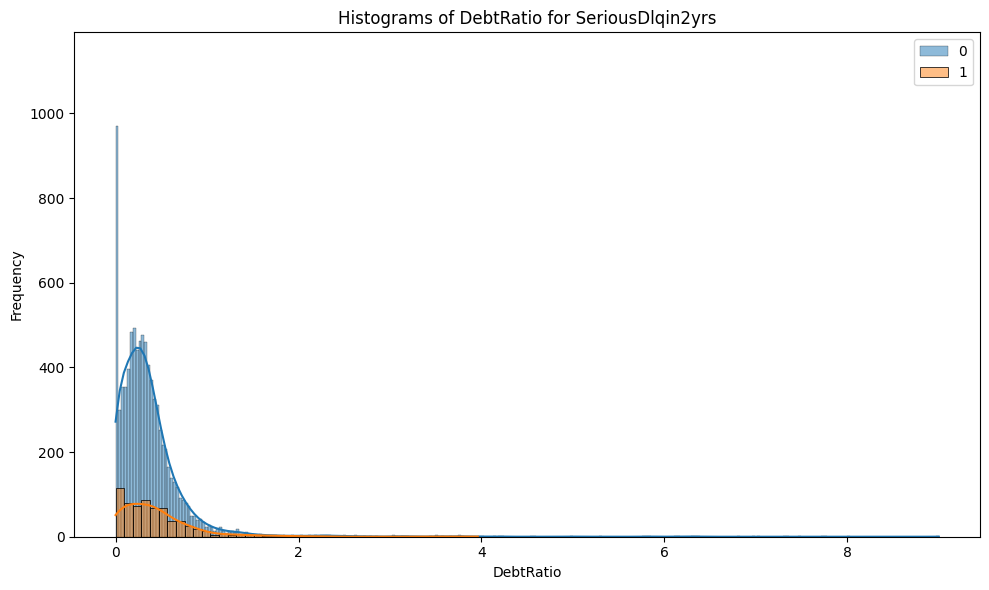

In [48]:
sin_debtratio_outliers = train_set["DebtRatio"] < 10
bt.plot_grouped_histograms(train_set[sin_debtratio_outliers], cat_col= target, num_col= "DebtRatio", group_size= 2)

*Tengo mis dudas, aunque el pico en 0 de pagadores me invita a quedarmela, haré también un test:*

In [49]:
cat_col = target
num_col = "DebtRatio"

grupo_a = train_set.loc[train_set[cat_col] == 0][num_col]
grupo_b = train_set.loc[train_set[cat_col] == 1][num_col]

u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 2593400.5
Valor p: 1.7354144957311655e-06


In [50]:
p_valor < 0.05

True

*Me la quedo (p-value <<<< 0.05)*

In [51]:
features_visual.append("DebtRatio")

In [52]:
features_visual

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

*Sobre lo que tengo hago un análisis de umbral de Varianza*

In [53]:
np.arange(0,1,0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [54]:
for umbral_varianza in np.arange(0,1,0.1):
    print(f"Para umbral = {umbral_varianza}")
    var_selector = VarianceThreshold(umbral_varianza)
    var_selector.fit(train_set[features_visual])
    print("Lista seleccionada por selector de Varianza", var_selector.get_feature_names_out())

Para umbral = 0.0
Lista seleccionada por selector de Varianza ['N30-59' 'N60-89' 'N90' 'RevolvingUtilizationOfUnsecuredLines' 'age'
 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.1
Lista seleccionada por selector de Varianza ['N30-59' 'RevolvingUtilizationOfUnsecuredLines' 'age' 'MonthlyIncome'
 'DebtRatio']
Para umbral = 0.2
Lista seleccionada por selector de Varianza ['N30-59' 'age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.30000000000000004
Lista seleccionada por selector de Varianza ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.4
Lista seleccionada por selector de Varianza ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.5
Lista seleccionada por selector de Varianza ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.6000000000000001
Lista seleccionada por selector de Varianza ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.7000000000000001
Lista seleccionada por selector de Varianza ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.8
Lista seleccionada por selecto

*Vaya lo que ocurre es que las categóricas con pocas categorías y no equilibradas se las come este selector, por eso sólo aplicalo a las variables contínuas y nos confirma por varianza que no está mal quedárselas. Probablemente es uno de lo selectores que menos vas a usar.*

In [55]:
features_visual

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

4.4 **Selección por filtrado, Análisis ANOVA y Mutual Information**

*Anova sobre las numericas:*

In [56]:
features_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [57]:
X_train = train_set[features_num]
y_train = train_set[target]

In [58]:
f_classif(X_train, y_train)

(array([7.88269908e+02, 1.05857431e+02, 7.40742353e-05, 6.12426971e+00,
        1.06261534e+01, 2.01252855e+01, 3.14679481e-01]),
 array([1.16190331e-166, 1.06935427e-024, 9.93133162e-001, 1.33512520e-002,
        1.11893938e-003, 7.33882974e-006, 5.74836065e-001]))

In [59]:
X_train = train_set[features_num]
y_train = train_set[target]

selector_num = SelectKBest(f_classif, k=4)
x_data_kbest = selector_num.fit_transform(X_train, y_train)

X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector_num.get_feature_names_out())
X_train_kbest

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfOpenCreditLinesAndLoans,NumberOfDependents
0,0.039187,61.0,7.0,0.0
1,0.919317,41.0,3.0,0.0
2,0.253718,49.0,19.0,0.0
3,0.249462,26.0,4.0,0.0
4,0.224520,76.0,6.0,0.0
...,...,...,...,...
9447,0.174437,61.0,7.0,0.0
9448,0.039651,64.0,6.0,0.0
9449,1.000000,29.0,0.0,6.0
9450,0.945805,51.0,16.0,0.0


In [60]:
features_filter = list(selector_num.get_feature_names_out())
features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents']

*Mutual Information para las categóricas:*

In [61]:
features_cat

['N30-59', 'N60-89', 'N90']

In [62]:
from sklearn.feature_selection import mutual_info_classif

X_train = train_set[features_cat]
y_train = train_set[target]

selector_cat = SelectKBest(mutual_info_classif, k=3)
x_data_kbest = selector_cat.fit_transform(X_train, y_train)

X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector_cat.get_feature_names_out())
X_train_kbest

,N30-59,N60-89,N90
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
9447,0,0,0
9448,0,0,0
9449,0,0,0
9450,2,0,0


*Nos quedamos las tres, sabiendo que podemos esperar más de N90 que de N30 y de N60.*

In [63]:
features_filter += features_cat

In [64]:
mutual_info_classif(X_train, y_train, random_state=42)

array([0.02099067, 0.02201709, 0.03364673])

*La información mutua, en el contexto de la teoría de la información, mide la cantidad de información que una variable aleatoria revela sobre otra.*  

*Se puede expresar en bits, nats o bans, dependiendo de la base del logaritmo utilizado.*  

*En el caso de mutual_info_classif, el resultado se expresa en nats, o unidades naturales de información, que se obtienen al usar logaritmos naturales (base e).*  

*Si quisieramos expresar el resultado en bits, solo sería necesario dividir los nats por el logaritmo en base 2*

In [65]:
# Información Mutua en bits

mutual_info_classif(X_train, y_train, random_state=42) / np.log(2)

array([0.03028313, 0.03176395, 0.04854197])

*En resumen, podríamos establecer un punto arbitrario de corte por ejeplo por debajo de 0,1 nat, pero es totalmente regla del "dedo gordo" y dependerá siempre de nuestros datos. De hacerlo así nos quedaríamos con las tres variables*

In [66]:
features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

4.5 **Selección por modelo**

*Vamos a hacerlo primero con sklearn y SelectFromModel empleando las features con las variables ya categorizadas (N30...). Ojo al hiperparámetro class_weight que empleamos ya al estar tan desbalanceado del dataset de entrada*

In [116]:
features = features_num + features_cat

rf_selector = RandomForestClassifier(max_depth= 10, random_state= 42, class_weight= "balanced") #

selector_modelo = SelectFromModel(estimator = rf_selector, threshold="median") # Nos quedamos con la mitad

selector_modelo.fit(train_set[features], train_set[target]) # X_train e y_train en los argumentos

features_modelo = list(selector_modelo.get_feature_names_out())
features_modelo

['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

*Hmmm, bastante diferente de nuestras selecciones anteriores, las categóricas que prometían más se han caído en esta selección salvo una*

*Veamos como sería manualmente:*

In [68]:
rf_check = RandomForestClassifier(max_depth= 10, random_state= 42, class_weight= "balanced")

rf_check.fit(train_set[features], train_set[target])

df_importance= pd.DataFrame(rf_check.feature_importances_, columns = ["importance"], index = features).sort_values("importance",ascending = False)
df_importance

,importance
RevolvingUtilizationOfUnsecuredLines,0.314137
N90,0.124283
N30-59,0.121731
age,0.092360
DebtRatio,0.090957
MonthlyIncome,0.081050
NumberOfOpenCreditLinesAndLoans,0.064247
N60-89,0.056510
NumberRealEstateLoansOrLines,0.031123
NumberOfDependents,0.023602


*Cortando por la mediana*

In [69]:
df_importance.importance.median()

0.08600362851534255

In [70]:
df_importance[df_importance.importance > df_importance.importance.median()]

,importance
RevolvingUtilizationOfUnsecuredLines,0.314137
N90,0.124283
N30-59,0.121731
age,0.092360
DebtRatio,0.090957


4.6 **RFE**

In [123]:
rf_RFE = RandomForestClassifier(max_depth=10, random_state= 42, class_weight= "balanced")

rfe = RFE(estimator = rf_RFE,
          n_features_to_select= 6, # Iterará hasta quedarse con 6
          step = 1)
# (n_features - numero_de_features_quiero)/step

rfe.fit(train_set[features], train_set[target])

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",6
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


*NOTA: Podríamos haber probado con todas las featues que ahora incluirían la versión numérica y la categorizada de NumberOf...*

In [124]:
features_RFE = list(rfe.get_feature_names_out())
features_RFE

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'N30-59',
 'N90']

In [73]:
features_modelo

['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

*No es igual que la selección por modelo*

4.7 **Selección Secuencial (SFS)**

In [74]:
train_set[features].columns.tolist()

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

In [75]:
40 + 36 + 32 + 28 + 24

160

In [76]:
from sklearn.feature_selection import SequentialFeatureSelector

rf_SFS = RandomForestClassifier(max_depth = 10, class_weight= "balanced", random_state = 42)

sfs_forward = SequentialFeatureSelector(rf_SFS,
                                        n_features_to_select = 5,
                                        cv = 4,
                                        scoring = "balanced_accuracy", # o en regresión p.ej. "neg_root_mean_squared_error"
                                        n_jobs = -1)
# cuántos modelos entreno:
# 1a feature: 10 * 4 = 40
# 2a feature: 9 * 4 = 36
# 3a feature: 8 * 4 = 32
# 4a feature: 7 * 4 = 28
# 5a feature: 6 * 4 = 24

sfs_forward.fit(train_set[features], train_set[target])

,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [77]:
features_SFS = list(sfs_forward.get_feature_names_out())
features_SFS

['NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

In [78]:
features_RFE

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'N30-59',
 'N90']

In [79]:
features_modelo

['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

In [80]:
features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

In [81]:
features_visual

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

*Tenemos para todos los gustos*

4.8 **Hard Voting**


*El hard-voting no es más que contar las veces que aparece repetida cada feature en las selecciones anteriores y qeudarnos con las "más votadas". En este caso nos quedaremos con las 6 más votadas, por lo que nos dice el eneunciado de no superar 6 features. Usaremos `Counter` del módulo collections*

In [82]:
lista_total = features_visual + features_filter + features_modelo + features_RFE + features_SFS
votaciones = Counter(lista_total)
votaciones

Counter({'N30-59': 5,
         'N90': 5,
         'RevolvingUtilizationOfUnsecuredLines': 4,
         'age': 4,
         'N60-89': 3,
         'DebtRatio': 3,
         'MonthlyIncome': 2,
         'NumberOfDependents': 2,
         'NumberOfOpenCreditLinesAndLoans': 1,
         'NumberRealEstateLoansOrLines': 1})

In [83]:
escrutinio = pd.DataFrame(votaciones.values(), columns = ["Votos"], index = votaciones.keys()).sort_values("Votos", ascending = False)
escrutinio


,Votos
N30-59,5
N90,5
RevolvingUtilizationOfUnsecuredLines,4
age,4
N60-89,3
DebtRatio,3
MonthlyIncome,2
NumberOfDependents,2
NumberOfOpenCreditLinesAndLoans,1
NumberRealEstateLoansOrLines,1


In [84]:
features_hard_voting = escrutinio["Votos"].nlargest(6).index.to_list()
features_hard_voting

['N30-59',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'N60-89',
 'DebtRatio']

5. **Modelado**



*Por simplificar y para evitarnos el escalado vamos a probar con RandomForest, XGBoost y LightGBM*

In [ ]:
nombres = [f"Seleccion {nombre}" for nombre in ["visual", "filter", "modelo", "rfe", "sfs", "voting"]]
model_names = ["Random Forest","XGBoost", "LightGBM"]

rf_clf = RandomForestClassifier(max_depth= 10, class_weight= "balanced", random_state= 42)
xg_clf = XGBClassifier(max_depth= 4, random_state  = 42, scale_pos_weight = len(train_set[train_set[target] == 0])/len(train_set[train_set[target] == 1]))
lgb_clf = LGBMClassifier(class_weight= "balanced", random_state= 42, verbose = -100, n_jobs= -1)

models = [rf_clf, xg_clf, lgb_clf]
resultados = []

for indice, lista in enumerate([features_visual, features_filter, features_modelo, features_RFE, features_SFS, features_hard_voting]):
    X_train = train_set[lista]
    y_train = train_set[target]
    
    for model_name, modelo in zip(model_names, models):
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy"))
        data = {
            "features_list": nombres[indice],
            "model": model_name,
            "avg. recall": metrica
        }
        print(data)
        resultados.append(data.copy())
df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("avg. recall", ascending = False)


{'features_list': 'Seleccion visual', 'model': 'Random Forest', 'avg. recall': 0.686853387088051}
{'features_list': 'Seleccion visual', 'model': 'XGBoost', 'avg. recall': 0.7120556373175857}
{'features_list': 'Seleccion visual', 'model': 'LightGBM', 'avg. recall': 0.7212281239736533}
{'features_list': 'Seleccion filter', 'model': 'Random Forest', 'avg. recall': 0.6892447860506647}
{'features_list': 'Seleccion filter', 'model': 'XGBoost', 'avg. recall': 0.7228967608818244}
{'features_list': 'Seleccion filter', 'model': 'LightGBM', 'avg. recall': 0.7342237834010819}
{'features_list': 'Seleccion modelo', 'model': 'Random Forest', 'avg. recall': 0.692174640239038}
{'features_list': 'Seleccion modelo', 'model': 'XGBoost', 'avg. recall': 0.7012361878659934}
{'features_list': 'Seleccion modelo', 'model': 'LightGBM', 'avg. recall': 0.717122564481002}
{'features_list': 'Seleccion rfe', 'model': 'Random Forest', 'avg. recall': 0.6796978092155563}
{'features_list': 'Seleccion rfe', 'model': 'XGBo

,features_list,model,avg. recall
5,Seleccion filter,LightGBM,0.734224
13,Seleccion sfs,XGBoost,0.727558
14,Seleccion sfs,LightGBM,0.726506
4,Seleccion filter,XGBoost,0.722897
2,Seleccion visual,LightGBM,0.721228
17,Seleccion voting,LightGBM,0.717768
8,Seleccion modelo,LightGBM,0.717123
16,Seleccion voting,XGBoost,0.716762
11,Seleccion rfe,LightGBM,0.714464
1,Seleccion visual,XGBoost,0.712056


*Nos quedamos con LightGBM y la selección secuencial, pero como estatiende al overfitting, también vamos a probar con la selección por filtrado*

In [86]:
features_SFS

['NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

6. **Ajuste fino y evaluación**

*Sobre SFS*

In [87]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15],
    "num_leaves": [15, 31, 63],
    "min_data_in_leaf": [10, 20, 100],
    "class_weight": ["balanced", None]
}

lgb_clf = LGBMClassifier(verbose=-100, random_state=42)

lgb_grid = GridSearchCV(
    lgb_clf,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)
lgb_grid.fit(train_set[features_SFS], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbose=-100)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [88]:
lgb_grid.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.01,
 'max_depth': 5,
 'min_data_in_leaf': 100,
 'n_estimators': 200,
 'num_leaves': 15}

In [89]:
lgb_grid.best_score_

0.7436721021638044

In [90]:
X_test = test_set[features_SFS]
y_test = test_set[target]

In [91]:
y_pred = lgb_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.83      0.90      2198
           1       0.22      0.63      0.33       166

    accuracy                           0.82      2364
   macro avg       0.59      0.73      0.61      2364
weighted avg       0.91      0.82      0.86      2364



In [92]:
features_SFS

['NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

*Sobre filtrado*

In [93]:

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15],
    "num_leaves": [15, 31, 63],
    "min_data_in_leaf": [10, 20, 100],
    "class_weight": ["balanced", None]
}

lgb_clf = LGBMClassifier(verbose = -100, n_jobs = -1)

lgb_grid_2 = GridSearchCV(lgb_clf,
                       param_grid= param_grid,
                       cv = 5,
                       scoring= "balanced_accuracy",
                       n_jobs=1)

lgb_grid_2.fit(train_set[features_filter],y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbose=-100)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [94]:
lgb_grid_2.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.01,
 'max_depth': 15,
 'min_data_in_leaf': 100,
 'n_estimators': 200,
 'num_leaves': 15}

In [95]:
lgb_grid_2.best_score_

0.7756709227576074

In [96]:
X_test = test_set[features_filter]
y_test = test_set[target]

In [97]:
y_pred = lgb_grid_2.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      2198
           1       0.21      0.71      0.33       166

    accuracy                           0.79      2364
   macro avg       0.59      0.76      0.60      2364
weighted avg       0.92      0.79      0.84      2364



In [98]:
features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

*Sobre todas las variables*

In [99]:

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15],
    "num_leaves": [15, 31, 63],
    "min_data_in_leaf": [10, 20, 100],
    "class_weight": ["balanced", None]
}

lgb_clf = LGBMClassifier(verbose = -100, n_jobs = -1)

lgb_grid_3 = GridSearchCV(lgb_clf,
                       param_grid= param_grid,
                       cv = 5,
                       scoring= "balanced_accuracy",
                       n_jobs=1)

lgb_grid_3.fit(train_set[features],y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbose=-100)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [100]:
lgb_grid_3.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.01,
 'max_depth': 10,
 'min_data_in_leaf': 100,
 'n_estimators': 200,
 'num_leaves': 15}

In [101]:
lgb_grid_3.best_score_

0.7761494567168763

In [102]:
X_test = test_set[features]
y_test = test_set[target]

In [103]:
y_pred = lgb_grid_3.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2198
           1       0.20      0.73      0.32       166

    accuracy                           0.78      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.78      0.83      2364



In [104]:
features

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [105]:
from sklearn.preprocessing import StandardScaler

X_train = train_set[features]
X_test = test_set[features]
y_train = train_set[target]
y_test = test_set[target]

# Escalamos antes de PCA: sin esto, MonthlyIncome (varianza ~1.6e8 en bruto)
# domina la varianza total y la primera componente principal termina siendo
# prácticamente un alias de esa única variable.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [106]:
pca.explained_variance_ratio_

array([0.19996622, 0.14943298, 0.11955877, 0.10242465, 0.0915658 ,
       0.07949892, 0.07115988, 0.0697001 , 0.06242945, 0.05426323])

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.19996622 0.3493992  0.46895797 0.57138262 0.66294842 0.74244734
 0.81360722 0.88330732 0.94573677 1.        ]


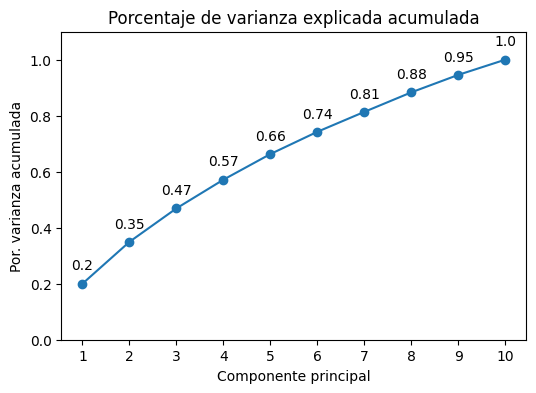

In [107]:
prop_varianza_acum = pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(len(X_train.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(X_train.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

*Con una componente....*

In [108]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
lgb_clf_pca = LGBMClassifier(**lgb_grid_2.best_params_, verbose = -100)

In [109]:
lgb_clf_pca.fit(X_train_pca[:, :1], y_train)
y_pred = lgb_clf_pca.predict(X_test_pca[:, :1])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2198
           1       0.23      0.64      0.34       166

    accuracy                           0.82      2364
   macro avg       0.60      0.74      0.62      2364
weighted avg       0.92      0.82      0.86      2364



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


*A pesar de que la primera componente ya contiene toda la varianza, **eso no quiere decir que lleve todo el poder explicativo** y no obtendremos unos resultados similares hasta que empleemos 6-7 PCs*

In [126]:
lgb_clf_pca = LGBMClassifier(**lgb_grid_2.best_params_, verbose = -100)

In [129]:
lgb_clf_pca.fit(X_train_pca[:,:1], y_train)
y_pred = lgb_clf_pca.predict(X_test_pca[:,:1])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2198
           1       0.23      0.64      0.34       166

    accuracy                           0.82      2364
   macro avg       0.60      0.74      0.62      2364
weighted avg       0.92      0.82      0.86      2364



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
lgb_clf_pca.fit(X_train_pca[:,:7], y_train)
y_pred = lgb_clf_pca.predict(X_test_pca[:,:7])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88      2198
           1       0.22      0.74      0.34       166

    accuracy                           0.80      2364
   macro avg       0.60      0.77      0.61      2364
weighted avg       0.92      0.80      0.84      2364



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
